# **Importación de librerías y cambio del dataset**

Se importan las librerías necesarias y se descarga el dataset desde Kaggle. Posteriormente, se construye la ruta hacia la carpeta **`melanoma_cancer_dataset`** para realizar la carga y preparación de las imágenes utilizadas en el entrenamiento y evaluación del modelo.


In [119]:
import numpy as np
import torch
import os
import pandas as pd
import random
import torch.nn as nn
from sklearn.metrics import roc_curve, roc_auc_score
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from tqdm import tqdm
import kagglehub

path = kagglehub.dataset_download("hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images")
path = os.path.join(path, "melanoma_cancer_dataset")

print("Ruta:", path)

Using Colab cache for faster access to the 'melanoma-skin-cancer-dataset-of-10000-images' dataset.
Ruta: /kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset


In [120]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [121]:
from torch.utils.data import DataLoader, Subset
dataset = ImageFolder(os.path.join(path, "train"))
num_classes = len(dataset.classes)
print("Clases:", dataset.classes)
print("Total de imágenes:", len(dataset))
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(dataset), generator=generator).tolist()
train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Clases: ['benign', 'malignant']
Total de imágenes: 9605
Train: 6723
Validation: 1440
Test: 1442


## **Aumentación de datos**

Se aplican diferentes técnicas de aumentación de imágenes para analizar su efecto sobre la capacidad de generalización de la CNN.


In [122]:
transform_basic = T.Compose([
    T.ToTensor()
])

dataset_basic = ImageFolder(os.path.join(path, "train"), transform=transform_basic)

train_dataset = Subset(dataset_basic, train_idx)
val_dataset = Subset(dataset_basic, val_idx)
test_dataset = Subset(dataset_basic, test_idx)

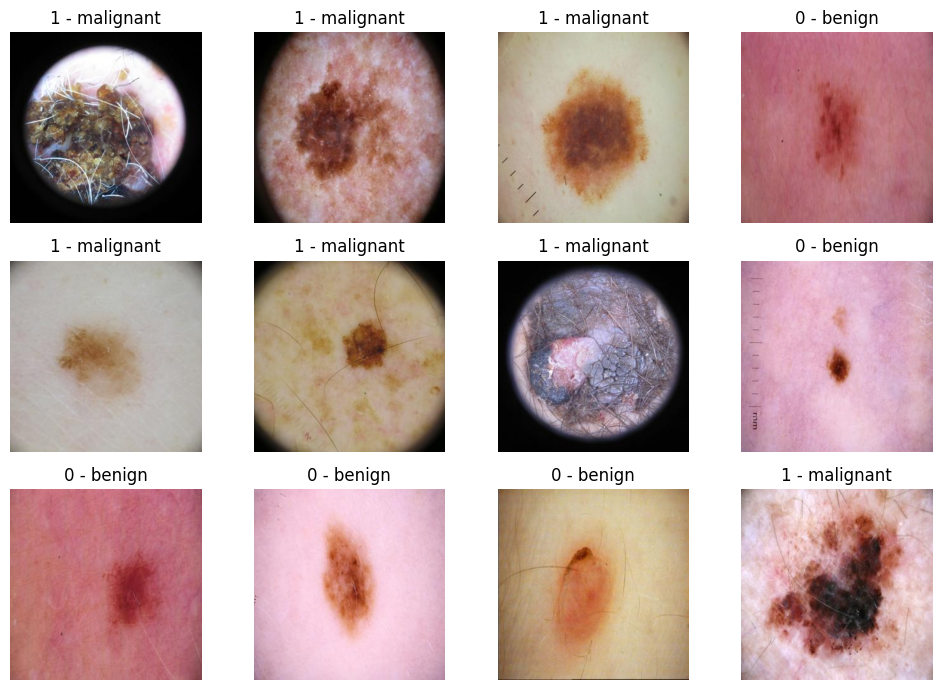

In [123]:
def show_random_images(dataset, n=12):
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    classes = dataset.dataset.classes

    plt.figure(figsize=(10, 7))

    for i, idx in enumerate(indices):
        x, y = dataset[idx]
        plt.subplot(3, 4, i + 1)
        plt.imshow(x.permute(1, 2, 0))
        plt.title(f"{y} - {classes[y]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_images(train_dataset, n=12)

In [124]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [125]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape

(torch.Size([32, 3, 300, 300]), torch.Size([32]))

# **Ejercicio 01: Cambio de arquitectura de la CNN**

Se modifica la arquitectura de la CNN incorporando capas BatchNorm y Dropout con el objetivo de analizar su efecto en el entrenamiento y rendimiento del modelo.

In [126]:
num_classes = len(dataset.classes)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [127]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()
        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()
        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))

In [128]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=0.001)

epochs = 15
history_scratch = {"loss": [], "accuracy": [], "auc": []}

for epoch in range(epochs):
    loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    acc, auc, _, _, _ = evaluate(model_scratch, val_loader)
    history_scratch["loss"].append(loss)
    history_scratch["accuracy"].append(acc)
    history_scratch["auc"].append(auc)
    print(
        f"Época {epoch + 1}: "
        f"Loss={loss:.4f} | "
        f"Accuracy={acc:.4f} | "
        f"AUC={auc:.4f}"
    )

Época 1: Loss=0.3015 | Accuracy=0.8729 | AUC=0.9435
Época 2: Loss=0.3103 | Accuracy=0.8833 | AUC=0.9508
Época 3: Loss=0.3075 | Accuracy=0.8910 | AUC=0.9498
Época 4: Loss=0.3000 | Accuracy=0.8875 | AUC=0.9493
Época 5: Loss=0.3020 | Accuracy=0.8840 | AUC=0.9514
Época 6: Loss=0.2971 | Accuracy=0.8792 | AUC=0.9484
Época 7: Loss=0.3038 | Accuracy=0.8903 | AUC=0.9523
Época 8: Loss=0.2901 | Accuracy=0.8903 | AUC=0.9503
Época 9: Loss=0.2936 | Accuracy=0.8840 | AUC=0.9467
Época 10: Loss=0.2997 | Accuracy=0.8750 | AUC=0.9510
Época 11: Loss=0.2953 | Accuracy=0.8847 | AUC=0.9525
Época 12: Loss=0.2878 | Accuracy=0.8868 | AUC=0.9540
Época 13: Loss=0.2914 | Accuracy=0.8840 | AUC=0.9521
Época 14: Loss=0.2925 | Accuracy=0.8875 | AUC=0.9541
Época 15: Loss=0.2883 | Accuracy=0.8847 | AUC=0.9523


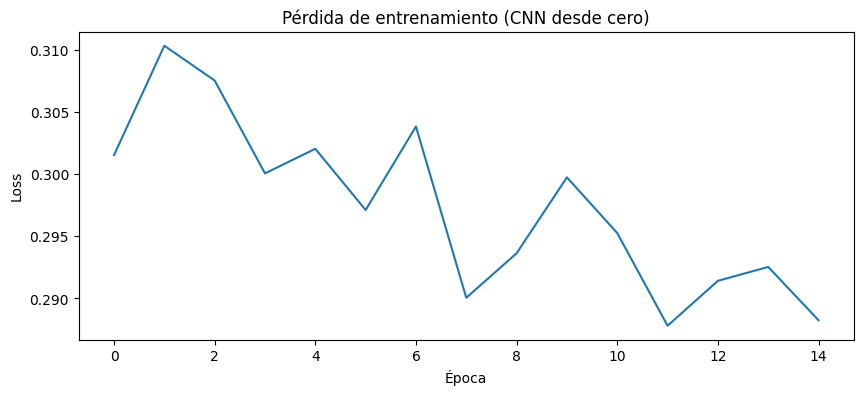

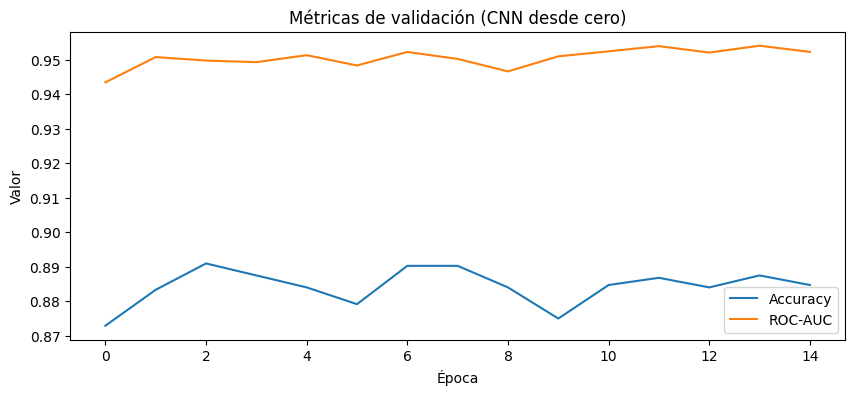

In [129]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["accuracy"], label="Accuracy")
plt.plot(history_scratch["auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()

In [130]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm

Test accuracy: 0.8842
Test ROC-AUC: 0.9497

              precision    recall  f1-score   support

           0     0.8656    0.9237    0.8937       760
           1     0.9081    0.8402    0.8728       682

    accuracy                         0.8842      1442
   macro avg     0.8868    0.8819    0.8833      1442
weighted avg     0.8857    0.8842    0.8838      1442



array([[702,  58],
       [109, 573]])

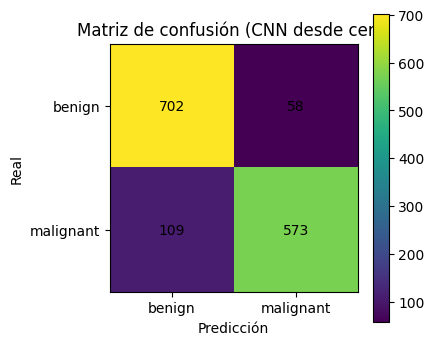

In [131]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1], dataset.classes)
plt.yticks([0, 1], dataset.classes)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()

## **Learning rate + Scheduler**

Se experimenta con dos valores de learning rate, 0.001 y 0.0001, para analizar su impacto en el proceso de entrenamiento. Además, se incorpora un scheduler para observar cómo la modificación de la tasa de aprendizaje influye en el rendimiento del modelo.

In [132]:
def train_with_scheduler(model, train_loader, val_loader, lr, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
    history = {"loss": [], "accuracy": [], "auc": [], "lr": []}
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc, val_auc, _, _, _ = evaluate(model, val_loader)
        current_lr = optimizer.param_groups[0]["lr"]
        history["loss"].append(train_loss)
        history["accuracy"].append(val_acc)
        history["auc"].append(val_auc)
        history["lr"].append(current_lr)
        print(
            f"Época {epoch + 1}/{epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Val Accuracy: {val_acc:.4f} | "
            f"Val AUC: {val_auc:.4f} | "
            f"LR: {current_lr:.6f}"
        )
        scheduler.step()
    return history

In [133]:
model_lr_001 = SimpleCNN(num_classes=num_classes).to(device)
history_lr_001 = train_with_scheduler(model=model_lr_001, train_loader=train_loader, val_loader=val_loader, lr=0.001, epochs=10)

Época 1/10 | Loss: 0.4350 | Val Accuracy: 0.8222 | Val AUC: 0.9055 | LR: 0.001000
Época 2/10 | Loss: 0.4072 | Val Accuracy: 0.8069 | Val AUC: 0.9095 | LR: 0.001000
Época 3/10 | Loss: 0.3798 | Val Accuracy: 0.8535 | Val AUC: 0.9230 | LR: 0.001000
Época 4/10 | Loss: 0.3483 | Val Accuracy: 0.8646 | Val AUC: 0.9434 | LR: 0.000100
Época 5/10 | Loss: 0.3355 | Val Accuracy: 0.8771 | Val AUC: 0.9484 | LR: 0.000100
Época 6/10 | Loss: 0.3291 | Val Accuracy: 0.8674 | Val AUC: 0.9470 | LR: 0.000100
Época 7/10 | Loss: 0.3201 | Val Accuracy: 0.8792 | Val AUC: 0.9506 | LR: 0.000010
Época 8/10 | Loss: 0.3196 | Val Accuracy: 0.8812 | Val AUC: 0.9500 | LR: 0.000010
Época 9/10 | Loss: 0.3212 | Val Accuracy: 0.8840 | Val AUC: 0.9500 | LR: 0.000010
Época 10/10 | Loss: 0.3219 | Val Accuracy: 0.8785 | Val AUC: 0.9499 | LR: 0.000001


In [134]:
model_lr_0001 = SimpleCNN(num_classes=num_classes).to(device)
history_lr_0001 = train_with_scheduler(model=model_lr_0001, train_loader=train_loader, val_loader=val_loader, lr=0.0001, epochs=10)

Época 1/10 | Loss: 0.4942 | Val Accuracy: 0.8236 | Val AUC: 0.9029 | LR: 0.000100
Época 2/10 | Loss: 0.4282 | Val Accuracy: 0.8389 | Val AUC: 0.9083 | LR: 0.000100
Época 3/10 | Loss: 0.4187 | Val Accuracy: 0.8333 | Val AUC: 0.9103 | LR: 0.000100
Época 4/10 | Loss: 0.4097 | Val Accuracy: 0.8299 | Val AUC: 0.9111 | LR: 0.000010
Época 5/10 | Loss: 0.4091 | Val Accuracy: 0.8431 | Val AUC: 0.9146 | LR: 0.000010
Época 6/10 | Loss: 0.4099 | Val Accuracy: 0.8382 | Val AUC: 0.9145 | LR: 0.000010
Época 7/10 | Loss: 0.4030 | Val Accuracy: 0.8389 | Val AUC: 0.9147 | LR: 0.000001
Época 8/10 | Loss: 0.4031 | Val Accuracy: 0.8368 | Val AUC: 0.9140 | LR: 0.000001
Época 9/10 | Loss: 0.3999 | Val Accuracy: 0.8410 | Val AUC: 0.9148 | LR: 0.000001
Época 10/10 | Loss: 0.4044 | Val Accuracy: 0.8313 | Val AUC: 0.9138 | LR: 0.000000


In [135]:
results_lr = pd.DataFrame({"Learning Rate": [0.001, 0.0001],
                           "Mejor Accuracy": [max(history_lr_001["accuracy"]),
                                              max(history_lr_0001["accuracy"])
                                              ],
                           "Mejor ROC-AUC": [max(history_lr_001["auc"]),
                                             max(history_lr_0001["auc"])]
                           })

results_lr

,Learning Rate,Mejor Accuracy,Mejor ROC-AUC
0,0.0010,0.884028,0.950579
1,0.0001,0.843056,0.914790


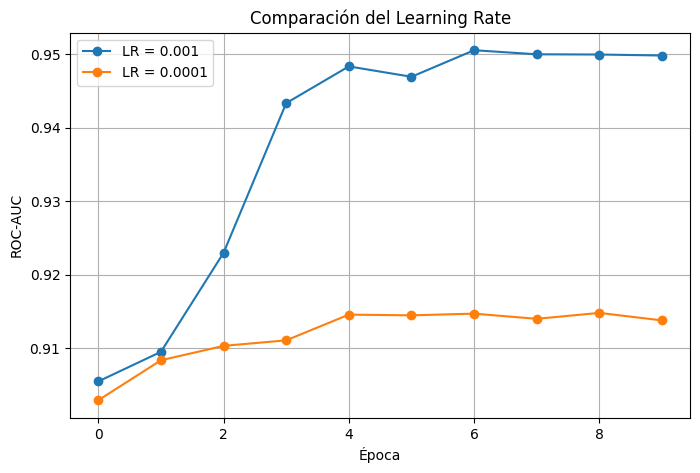

In [136]:
plt.figure(figsize=(8, 5))
plt.plot(history_lr_001["auc"], marker="o", label="LR = 0.001")
plt.plot(history_lr_0001["auc"], marker="o", label="LR = 0.0001")
plt.xlabel("Época")
plt.ylabel("ROC-AUC")
plt.title("Comparación del Learning Rate")
plt.legend()
plt.grid()
plt.show()

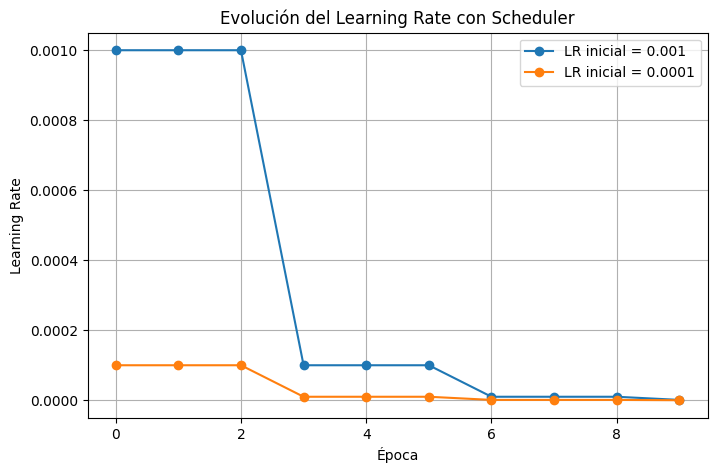

In [137]:
plt.figure(figsize=(8, 5))
plt.plot(history_lr_001["lr"], marker="o", label="LR inicial = 0.001")
plt.plot(history_lr_0001["lr"], marker="o", label="LR inicial = 0.0001")
plt.xlabel("Época")
plt.ylabel("Learning Rate")
plt.title("Evolución del Learning Rate con Scheduler")
plt.legend()
plt.grid()
plt.show()

In [138]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    T.ToTensor()
])

dataset_aug = ImageFolder(os.path.join(path, "train"), transform=transform_aug)
train_dataset_aug = Subset(dataset_aug, train_idx)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)

In [139]:
model_aug = SimpleCNN(num_classes).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=0.001)
epochs = 15
history_aug = {"loss": [], "accuracy": [], "auc": []}
for epoch in range(epochs):
    loss = train_one_epoch(model_aug, train_loader_aug, optimizer_aug, loss_fn)
    acc, auc, _, _, _ = evaluate(model_aug, val_loader)
    history_aug["loss"].append(loss)
    history_aug["accuracy"].append(acc)
    history_aug["auc"].append(auc)
    print(
        f"Época {epoch + 1}: "
        f"Loss={loss:.4f} | "
        f"Accuracy={acc:.4f} | "
        f"AUC={auc:.4f}"
    )

Época 1: Loss=0.4403 | Accuracy=0.8208 | AUC=0.9067
Época 2: Loss=0.4128 | Accuracy=0.7729 | AUC=0.9035
Época 3: Loss=0.4080 | Accuracy=0.7840 | AUC=0.9064
Época 4: Loss=0.3959 | Accuracy=0.8215 | AUC=0.8963
Época 5: Loss=0.3777 | Accuracy=0.8299 | AUC=0.9258
Época 6: Loss=0.3605 | Accuracy=0.8354 | AUC=0.9309
Época 7: Loss=0.3430 | Accuracy=0.7958 | AUC=0.9408
Época 8: Loss=0.3270 | Accuracy=0.8632 | AUC=0.9398
Época 9: Loss=0.3152 | Accuracy=0.8389 | AUC=0.9421
Época 10: Loss=0.3104 | Accuracy=0.4917 | AUC=0.4557
Época 11: Loss=0.2975 | Accuracy=0.8903 | AUC=0.9578
Época 12: Loss=0.2888 | Accuracy=0.8632 | AUC=0.9566
Época 13: Loss=0.2881 | Accuracy=0.7882 | AUC=0.9261
Época 14: Loss=0.2849 | Accuracy=0.9049 | AUC=0.9638
Época 15: Loss=0.2852 | Accuracy=0.8250 | AUC=0.9475


In [140]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")

Sin augmentation | test_acc=0.8842 | test_auc=0.9497
Con augmentation | test_acc=0.8058 | test_auc=0.9417


In [141]:
import torchvision.models as models
weights = models.ResNet18_Weights.DEFAULT
transform_tl = weights.transforms()
dataset_tl = ImageFolder(os.path.join(path, "train"), transform=transform_tl)
train_dataset_tl = Subset(dataset_tl, train_idx)
val_dataset_tl = Subset(dataset_tl, val_idx)
test_dataset_tl = Subset(dataset_tl, test_idx)
train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False)
print(next(iter(train_loader_tl))[0].shape)

torch.Size([64, 3, 224, 224])


In [142]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)
for name, param in resnet.named_parameters():
    param.requires_grad = False
for param in resnet.fc.parameters():
    param.requires_grad = True
resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [143]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)
epochs = 5
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}
for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)
    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)
    print(
        f"Época {epoch}: "
        f"Loss={train_loss:.4f} | "
        f"Val Accuracy={val_acc:.4f} | "
        f"Val AUC={val_auc:.4f}"
    )

Época 1: Loss=0.3736 | Val Accuracy=0.8854 | Val AUC=0.9615
Época 2: Loss=0.2822 | Val Accuracy=0.9014 | Val AUC=0.9649
Época 3: Loss=0.2664 | Val Accuracy=0.9035 | Val AUC=0.9663
Época 4: Loss=0.2652 | Val Accuracy=0.8924 | Val AUC=0.9659
Época 5: Loss=0.2629 | Val Accuracy=0.9076 | Val AUC=0.9678


In [144]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True
trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)

17

In [145]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)
epochs = 5
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}
for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet,val_loader_tl)
    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)
    print(
        f"Época {epoch}: "
        f"Loss={train_loss:.4f} | "
        f"Val Accuracy={val_acc:.4f} | "
        f"Val AUC={val_auc:.4f}"
    )

Época 1: Loss=0.2299 | Val Accuracy=0.9174 | Val AUC=0.9763
Época 2: Loss=0.0830 | Val Accuracy=0.9299 | Val AUC=0.9769
Época 3: Loss=0.0280 | Val Accuracy=0.9313 | Val AUC=0.9802
Época 4: Loss=0.0117 | Val Accuracy=0.9271 | Val AUC=0.9777
Época 5: Loss=0.0100 | Val Accuracy=0.9285 | Val AUC=0.9781


In [146]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, target_names=dataset.classes, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl

Transfer learning | test_acc=0.9320 | test_auc=0.9789

              precision    recall  f1-score   support

      benign     0.9265    0.9461    0.9362       760
   malignant     0.9384    0.9164    0.9273       682

    accuracy                         0.9320      1442
   macro avg     0.9325    0.9312    0.9317      1442
weighted avg     0.9322    0.9320    0.9320      1442



array([[719,  41],
       [ 57, 625]])

In [147]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug) | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug) | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")

Resumen de resultados en test
CNN desde cero (sin aug) | acc=0.8842 | auc=0.9497
CNN desde cero (con aug) | acc=0.8058 | auc=0.9417
Transfer learning (ResNet) | acc=0.9320 | auc=0.9789


In [148]:
def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)
    activations = {}
    gradients = {}
    def forward_hook(module, inp, out):
        activations["value"] = out
    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]
    target_layer = model.layer4[-1].conv2
    handle_fwd = target_layer.register_forward_hook(forward_hook)
    handle_bwd = target_layer.register_full_backward_hook(backward_hook)
    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())
    score = logits[0, target_class]
    model.zero_grad()
    score.backward()
    act = activations["value"][0]
    grad = gradients["value"][0]
    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act,dim=0)
    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    handle_fwd.remove()
    handle_bwd.remove()
    return cam.detach().cpu().numpy(), target_class

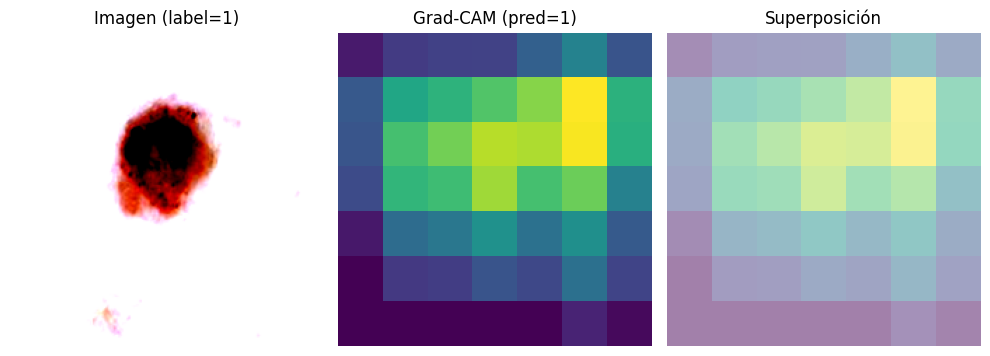

In [149]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)
img = x.permute(1, 2, 0).numpy()
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f"Imagen (label={int(y)})")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")
plt.tight_layout()
plt.show()

In [150]:
import os
os.makedirs("models", exist_ok=True)
torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")
["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]

['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## **Curva ROC + calibración**

Se revisa el modelo mediante la curva ROC y el área bajo la curva (AUROC). Además, se analiza la calibración de las probabilidades predichas para evaluar qué tan bien representan la confianza del modelo.

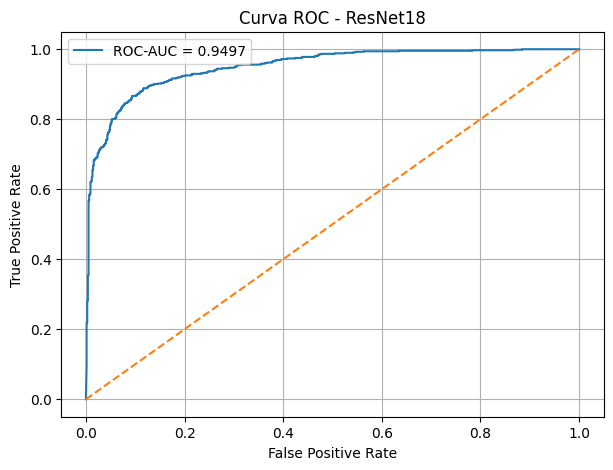

In [151]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - ResNet18")
plt.legend()
plt.grid()
plt.show()

In [152]:
from sklearn.calibration import calibration_curve

In [153]:
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")

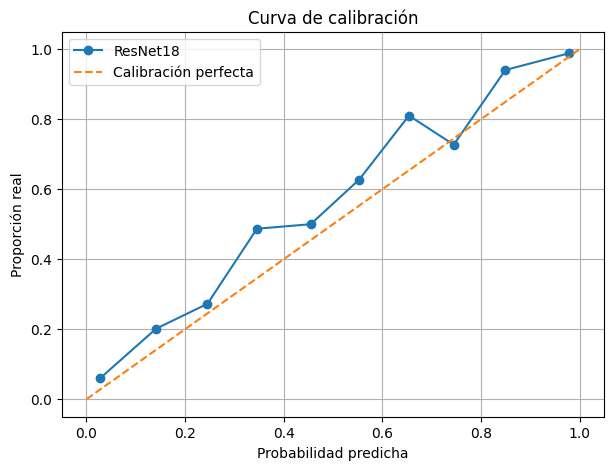

In [154]:
plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label="ResNet18")
plt.plot([0, 1], [0, 1], linestyle="--", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Proporción real")
plt.title("Curva de calibración")
plt.legend()
plt.grid()
plt.show()